<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/0508_%EC%84%B8%EC%85%98_RNN_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 넷플릭스 주가 예측하기 RNN 코드 실습

## 1. 데이터 가져오기

In [11]:
# 데이터 가져오기
import pandas as pd
data=pd.read_csv('netflix_train.csv')
data.head()

,Date,Open,High,Low,Volume,Close
0,2015-12-16,120,123,118,13181000,123
1,2015-12-17,124,126,122,17284900,123
2,2015-12-18,121,122,118,17948100,118
3,2015-12-21,120,120,116,11670000,117
4,2015-12-22,117,117,115,9689000,116


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    967 non-null    object
 1   Open    967 non-null    int64 
 2   High    967 non-null    int64 
 3   Low     967 non-null    int64 
 4   Volume  967 non-null    int64 
 5   Close   967 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 45.5+ KB


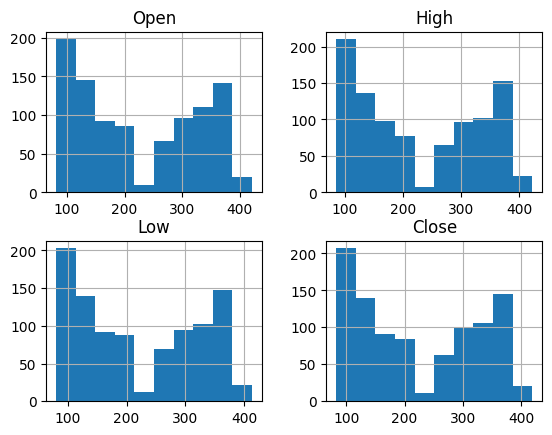

In [13]:
# 데이터 분포를 히스토그램으로 살펴보기
import matplotlib.pyplot as plt
data_used=data.drop(['Date','Volume'],axis=1)
# 개장가, 최고가, 최저가 추가
# 종가 추가
hist = data_used.hist()
plt.show()

## 2. 파이토치 데이터셋 구성하기

In [16]:
import numpy as np
import pandas as pd
from torch.utils.data.dataset import Dataset

class Netflix(Dataset):

    def __init__(self):
        # 데이터 읽기
        self.data = pd.read_csv("netflix_train.csv")

        data = self.data.iloc[:, 1:].values.astype(np.float32)

        # 입력 데이터 정규화
        # 종가를 제외한 데이터
        self.x = data[:, :-1]

        # 0과 1 사이로 정규화
        self.x = (self.x - self.x.min(axis=0)) / (
            self.x.max(axis=0) - self.x.min(axis=0)
        )

        # 종가 데이터 정규화
        self.y = data[:, -1]
        self.y = (self.y - self.y.min()) / (
            self.y.max() - self.y.min()
        )

    def __len__(self):
        return len(self.data) - 30   # 사용 가능한 배치 개수

    def __getitem__(self, i):
    # 입력 데이터 30일치
        data = self.x[i:i+30]

    # 30일 뒤, 즉 다음 날 종가 하나
        label = self.y[i+30]

        return data, label

## 3. RNN 모델 정의

In [17]:
import torch
import torch.nn as nn

class RNN(nn.Module):
   def __init__(self):
       super(RNN, self).__init__()

       # RNN층의 정의
       self.rnn = nn.RNN(
           input_size=4,
           hidden_size=8,
           num_layers=5,
           batch_first=True
       )

       # 주가를 예측하는 MLP층 정의
       self.fc1 = nn.Linear(8, 64)
       self.fc2 = nn.Linear(64, 1)

       # 활성화 함수 정의
       self.relu = nn.ReLU()

   # RNN 모델의 순전파 정의
   def forward(self, x, h0):
       # RNN층의 출력
       x, hn = self.rnn(x, h0)

       # MLP층의 입력으로 사용되게 모양 변경
       x = x[:, -1, :]

       # MLP층을 이용해 종가 예측
       x = self.fc1(x)
       x = self.relu(x)
       x = self.fc2(x)

       # 예측한 종가를 1차원 벡터로 표현
       x = x.view(-1)

       return x

## 4. 모델 학습하기

In [18]:
# 모델과 데이터셋 정의
import tqdm
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델의 정의
model = RNN().to(device)

# 데이터셋의 정의
dataset = Netflix()
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [19]:
# 데이터로더 정의
# 배치 크기를 32로 설정
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [20]:
# 최적화 정의
# 학습률은 0.0001로 설정

# 사용할 최적화 설정
optim = Adam(model.parameters(), lr=0.0001)

In [21]:
# 학습 루프 정의
# 에포크: 200

criterion = nn.MSELoss()

for epoch in range(200):

   iterator = tqdm.tqdm(loader)

   for data, label in iterator:

       optim.zero_grad()

       # GPU로 이동
       data = data.to(device).float()
       label = label.to(device).float()

       # 초기 은닉 상태
       h0 = torch.zeros(5, data.shape[0], 8).to(device)

       # 모델의 예측값
       pred = model(data, h0)

       # 손실의 계산
       loss = criterion(pred, label)

       # 오차 역전파
       loss.backward()

       # 최적화 진행
       optim.step()

       iterator.set_description(
           f"epoch:{epoch} loss:{loss.item()}"
       )

# 모델 저장
torch.save(model.state_dict(), "rnn.pth")

epoch:199 loss:0.000244724826188758: 100%|██████████| 30/30 [00:00<00:00, 45.66it/s]


## 5. 모델 성능 평가하기

In [26]:
import matplotlib.pyplot as plt

# 예측값을 위한 데이터로더
loader = DataLoader(dataset, batch_size=32)

# 예측값들을 저장하는 리스트
preds = []

total_loss = 0

criterion = nn.MSELoss()

with torch.no_grad():
    model.load_state_dict(torch.load("rnn.pth"))
    model.eval()

    for data, label in loader:
        data = data.to(device).float()
        label = label.to(device).float()

        h0 = torch.zeros(5, data.shape[0], 8).to(device)

        pred = model(data, h0)

        # 예측값을 숫자 리스트로 변환해서 추가
        preds.extend(pred.cpu().numpy())

       # 손실 계산
        loss = criterion(pred, label)

       # 손실의 평균치 계산
        total_loss += loss

total_loss.item()

0.027062050998210907

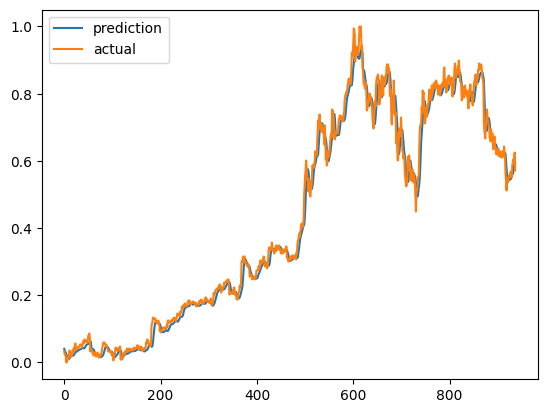

In [30]:
# 그래프 출력
plt.plot(preds, label="prediction")
plt.plot(dataset.y[30:], label="actual")
plt.legend()
plt.show()